<h1>Medical Image Segmentation AI Model</h1>

This code uses the dataset from Cybele

In developing the model I have used the MONAI Documentation continuously: https://docs.monai.io/en/stable/networks.html

Additionally I have used inspiration from MONAI's Tutorial Repository: https://github.com/Project-MONAI/tutorials/blob/main/3d_segmentation/unet_segmentation_3d_ignite.ipynb

I have also used ChatGPT for help with errors and some debugging

In [ ]:
import os
import glob
import numpy as np
import nibabel as nib
import torch
from torch import nn
import matplotlib.pyplot as plt
from monai.data import Dataset, DataLoader
from monai.transforms import (
    Compose, LoadImaged, EnsureChannelFirstd, NormalizeIntensityd, RandCoarseDropoutd,
    RandCropByPosNegLabeld, RandRotate90d, RandFlipd, RandGaussianNoised, CropForegroundd, Rand3DElasticd,
    ToTensord, EnsureTyped, Spacingd, SpatialPadd, RandAdjustContrastd, RandAffined
)
from monai.networks.nets import UNet, AttentionUnet
from monai.losses import DiceLoss, DiceFocalLoss, DiceCELoss
from monai.metrics import DiceMetric
from monai.inferers import sliding_window_inference
from torch.optim import AdamW
from torch.optim.lr_scheduler import StepLR, CosineAnnealingLR
from torch.amp import autocast, GradScaler
from sklearn.model_selection import train_test_split

<h3>Loading data</h3>

In [ ]:
# Use of ChatGPT for help with loading data
base_dir = "/datasets/tdt4265/mic/open/HNTS-MRG/train"

case_dirs = sorted(glob.glob(os.path.join(base_dir, "*")))
data = []

for case_dir in case_dirs:
    case_id = os.path.basename(case_dir) 
    image_path = os.path.join(case_dir, "preRT", f"{case_id}_preRT_T2.nii.gz")
    label_path = os.path.join(case_dir, "preRT", f"{case_id}_preRT_mask.nii.gz")

    if os.path.exists(image_path) and os.path.exists(label_path):
        data.append({"image": image_path, "label": label_path})
    else:
        print(f"Missing data for case {case_id}, skipping.")

print(f"Found {len(data)} samples.")
print(data[0])

# Split the data into training and validation sets
train_data, val_data = train_test_split(data, test_size=0.2, random_state=42)  # 80% train, 20% validation

Found 130 samples.
{'image': '/datasets/tdt4265/mic/open/HNTS-MRG/train/10/preRT/10_preRT_T2.nii.gz', 'label': '/datasets/tdt4265/mic/open/HNTS-MRG/train/10/preRT/10_preRT_mask.nii.gz'}


<h3>Data Transformations</h3>

In [ ]:
# Transforms for data preprocessing
train_transforms = Compose([
    LoadImaged(keys=["image", "label"]),
    EnsureChannelFirstd(keys=["image", "label"]),
    Spacingd(keys=["image", "label"], pixdim=(1.0,1.0,2.0), mode=("bilinear", "nearest")), # Voxel spacing that takes less memory and still somewhat according to EDA
    NormalizeIntensityd(keys=["image"]),
    CropForegroundd(keys=["image", "label"], source_key="image"), # Crop out parts with only background
    SpatialPadd(keys=["image", "label"], spatial_size=[256, 256, 64]), # Ensure at least as big sa crop
    RandCropByPosNegLabeld( # Crop instead of resize for medical consistency
        keys=["image", "label"],
        label_key="label",
        spatial_size=(256, 256, 64),
        pos=2, # force some positive crops
        neg=1, # allow negative crops
        num_samples=3, # number of patches per volume
        image_key="image",
    ),
    # Data augmentation (Heavy!)
    Rand3DElasticd(keys=["image", "label"], sigma_range=(2,5), magnitude_range=(50,150), prob=0.2),
    RandRotate90d(keys=["image", "label"], prob=0.4),
    RandFlipd(keys=["image", "label"], prob=0.4),
    RandGaussianNoised(keys=["image"], prob=0.2),
    RandAffined(keys=["image", "label"], rotate_range=(0.1, 0.1, 0.1), scale_range=(0.1, 0.1, 0.1), prob=0.3),
    RandAdjustContrastd(keys=["image"], prob=0.2, gamma=(0.7, 1.5)),
    RandCoarseDropoutd(keys=["image"], holes=5, spatial_size=(16, 16, 4), prob=0.1), # patch-dropout
    # Final transformations
    ToTensord(keys=["image", "label"]),
    EnsureTyped(keys=["image", "label"]),
])
val_transforms = Compose([
    LoadImaged(keys=["image", "label"]),
    EnsureChannelFirstd(keys=["image", "label"]),
    Spacingd(keys=["image", "label"], pixdim=(1.0,1.0,2.0), mode=("bilinear", "nearest")), # Same spacing as in training
    NormalizeIntensityd(keys=["image"]),
    ToTensord(keys=["image", "label"]),
    EnsureTyped(keys=["image", "label"]),
])

# Dataset and DataLoader
train_dataset = Dataset(data=train_data, transform=train_transforms) # Loading and transforming data
train_loader = DataLoader(train_dataset, batch_size=1, shuffle=True, num_workers=8, persistent_workers=True, pin_memory=True) # Loads 2 batches in parallel 

val_dataset = Dataset(data=val_data, transform=val_transforms)
val_loader = DataLoader(val_dataset, batch_size=1, shuffle=False, num_workers=4, persistent_workers=True, pin_memory=True) #batch size 1 allows different sized images in val


<h3>Building the Model</h3>

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print('Using device:', device)

# Define the UNet model (now Attention variant) with 3 output channels
model = AttentionUnet( # Change to attentionUnet -> stronger model, dealing with small tumors, attention -> using only relevant features from skips
    spatial_dims=3, # 3D model (volumetric MRI data)
    in_channels=1, # Single-channel input (T2 MRI image -> greyscale)
    out_channels=3, # 3 output channels: (background, tumor1, tumor2)
    channels=(32, 64, 128, 256, 512), # 5 levels deep
    strides=(2, 2, 2, 2), # (256,256,64) -> (128,128,32) -> (64,64,16) -> (32,32,8) -> (16,16,4) -> and up again 
    dropout=0.3, # Dropout for better generalization
).to(device)

# Loss function with softmax for multiclass, and one-hot-encoding
loss_function = DiceCELoss(include_background=True, to_onehot_y=True, softmax=True) # Experimenting with different loss functions

# Optimizer and scheduler
# Change to AdamW to try lr scheduler (not regular Adam as we want L2 regularization)
optimizer = AdamW(model.parameters(), lr=1e-4, weight_decay=1e-5) # wd to 1e-5 (enough to not overfit) isntead of 1e-2 as we have a small dataset and small tumors
scheduler = CosineAnnealingLR(optimizer, T_max=200) # First slow lr decay, then fast, then slower again (smooth lr change)

# Dice metric for evaluation
train_dice_metric = DiceMetric(include_background=True, reduction="mean")
val_dice_metric = DiceMetric(include_background=True, reduction="mean")

# Automatic Mixed Precicion (AMP) -> reduced memory and training time
scaler = GradScaler()


Using device: cuda


<h3>Early stopping</h3>

In [ ]:
class EarlyStopping:
    def __init__(self, patience=20, verbose=True, delta=0.0):
        self.patience = patience
        self.verbose = verbose
        self.delta = delta
        self.best_score = None
        self.counter = 0
        self.early_stop = False
        self.best_epoch = 0

    def __call__(self, val_dice, epoch):
        score = val_dice

        if self.best_score is None:
            self.best_score = score
            self.best_epoch = epoch
        elif score < self.best_score + self.delta:
            self.counter += 1
            if self.verbose:
                print(f"EarlyStopping counter: {self.counter}/{self.patience}")
            if self.counter >= self.patience:
                self.early_stop = True
        else:
            self.best_score = score
            self.best_epoch = epoch
            self.counter = 0


early_stopping = EarlyStopping(patience=20, verbose=True, delta=0.001)

<h3>Training the Model</h3>

Epoch 1/200
  Training Loss: 1.5523, Training Dice: 0.0068
  Validation Dice: 0.0000
EarlyStopping counter: 1/20


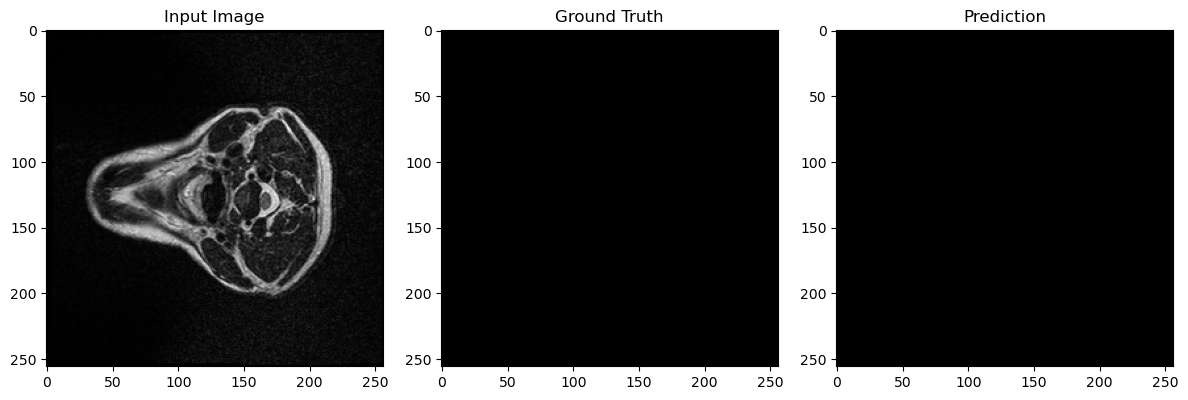

Epoch 2/200
  Training Loss: 1.2878, Training Dice: 0.0041
  Validation Dice: 0.0000
EarlyStopping counter: 2/20
Epoch 3/200
  Training Loss: 1.1769, Training Dice: 0.0025
  Validation Dice: 0.0000
EarlyStopping counter: 3/20
Epoch 4/200
  Training Loss: 1.0943, Training Dice: 0.0015
  Validation Dice: 0.0000
EarlyStopping counter: 4/20
Epoch 5/200
  Training Loss: 1.0300, Training Dice: 0.0010
  Validation Dice: 0.0000
EarlyStopping counter: 5/20
Epoch 6/200
  Training Loss: 0.9750, Training Dice: 0.0006
  Validation Dice: 0.0000
EarlyStopping counter: 6/20
Epoch 7/200
  Training Loss: 0.9285, Training Dice: 0.0003
  Validation Dice: 0.0000
EarlyStopping counter: 7/20
Epoch 8/200
  Training Loss: 0.8910, Training Dice: 0.0002
  Validation Dice: 0.0000
EarlyStopping counter: 8/20
Epoch 9/200
  Training Loss: 0.8576, Training Dice: 0.0002
  Validation Dice: 0.0000
EarlyStopping counter: 9/20
Epoch 10/200
  Training Loss: 0.8287, Training Dice: 0.0001
  Validation Dice: 0.0000
EarlyStopp

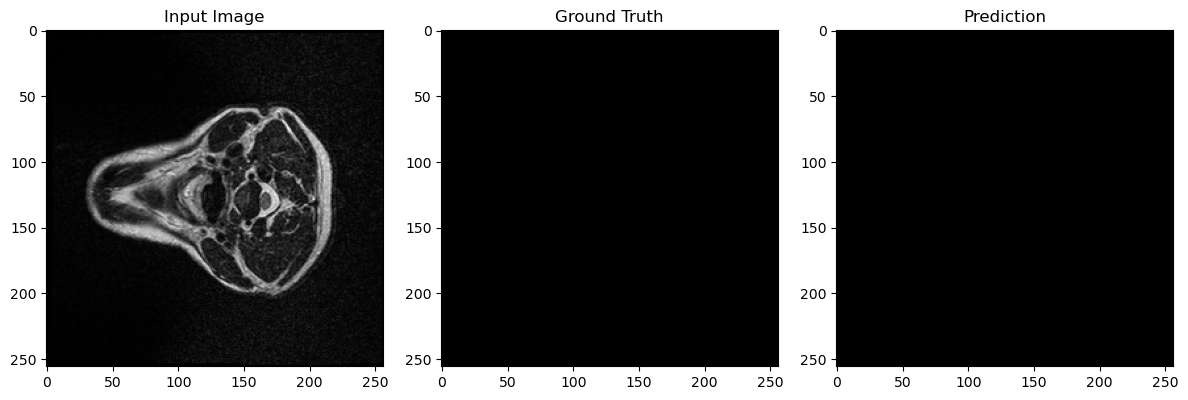

Epoch 12/200
  Training Loss: 0.7837, Training Dice: 0.0000
  Validation Dice: 0.0000
EarlyStopping counter: 12/20
Epoch 13/200
  Training Loss: 0.7654, Training Dice: 0.0000
  Validation Dice: 0.0000
EarlyStopping counter: 13/20
Epoch 14/200
  Training Loss: 0.7498, Training Dice: 0.0000
  Validation Dice: 0.0000
EarlyStopping counter: 14/20
Epoch 15/200
  Training Loss: 0.7368, Training Dice: 0.0000
  Validation Dice: 0.0000
EarlyStopping counter: 15/20
Saved new best model with Val Dice: 0.04516744613647461
Epoch 16/200
  Training Loss: 0.7243, Training Dice: 0.0146
  Validation Dice: 0.0452
Saved new best model with Val Dice: 0.09939590841531754
Epoch 17/200
  Training Loss: 0.7132, Training Dice: 0.0847
  Validation Dice: 0.0994
Saved new best model with Val Dice: 0.121212899684906
Epoch 18/200
  Training Loss: 0.7041, Training Dice: 0.1153
  Validation Dice: 0.1212
Saved new best model with Val Dice: 0.19218985736370087
Epoch 19/200
  Training Loss: 0.6963, Training Dice: 0.1724


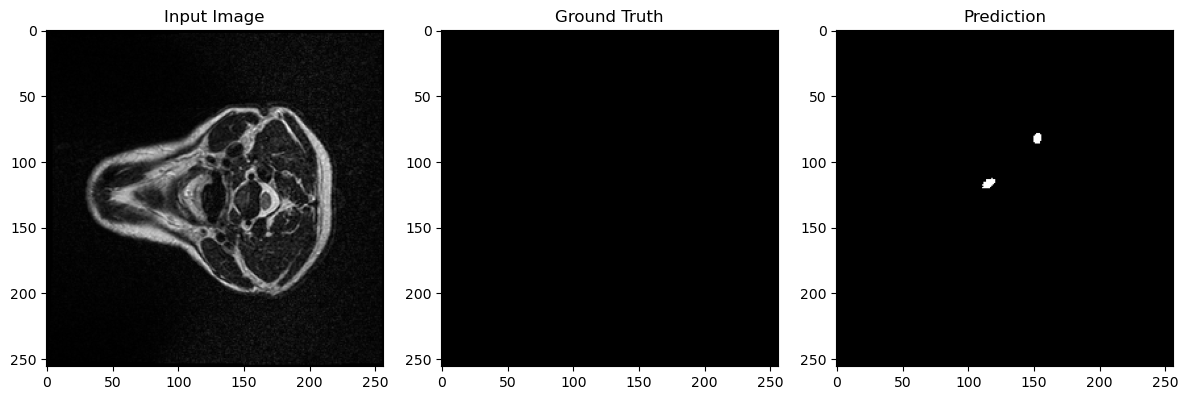

Epoch 22/200
  Training Loss: 0.6767, Training Dice: 0.1872
  Validation Dice: 0.1566
EarlyStopping counter: 3/20
Epoch 23/200
  Training Loss: 0.6731, Training Dice: 0.1625
  Validation Dice: 0.0363
EarlyStopping counter: 4/20
Epoch 24/200
  Training Loss: 0.6661, Training Dice: 0.1397
  Validation Dice: 0.0494
EarlyStopping counter: 5/20
Epoch 25/200
  Training Loss: 0.6630, Training Dice: 0.0904
  Validation Dice: 0.0188
EarlyStopping counter: 6/20
Epoch 26/200
  Training Loss: 0.6572, Training Dice: 0.1258
  Validation Dice: 0.0079
EarlyStopping counter: 7/20
Epoch 27/200
  Training Loss: 0.6513, Training Dice: 0.0670
  Validation Dice: 0.0005
EarlyStopping counter: 8/20
Epoch 28/200
  Training Loss: 0.6477, Training Dice: 0.0774
  Validation Dice: 0.0046
EarlyStopping counter: 9/20
Epoch 29/200
  Training Loss: 0.6456, Training Dice: 0.0489
  Validation Dice: 0.0042
EarlyStopping counter: 10/20
Epoch 30/200
  Training Loss: 0.6393, Training Dice: 0.1238
  Validation Dice: 0.0147
E

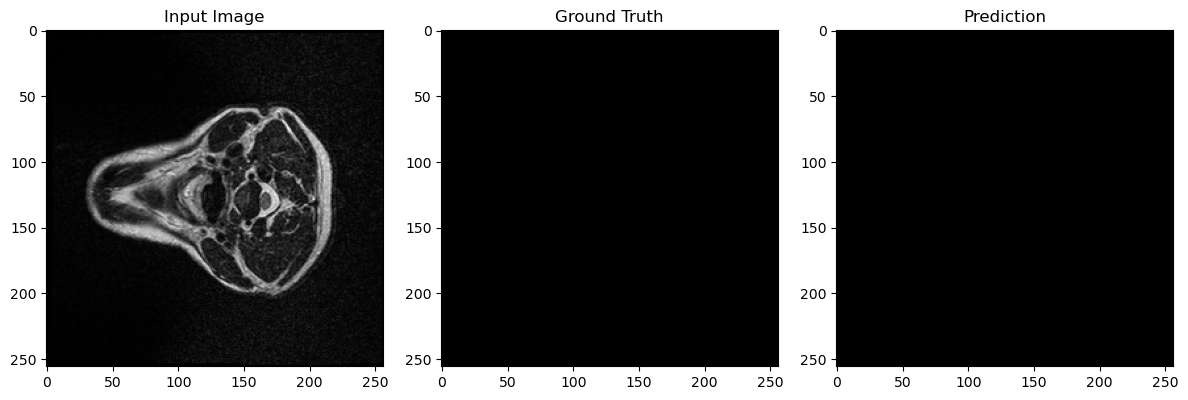

Epoch 32/200
  Training Loss: 0.6193, Training Dice: 0.1498
  Validation Dice: 0.0898
EarlyStopping counter: 13/20
Epoch 33/200
  Training Loss: 0.6059, Training Dice: 0.2124
  Validation Dice: 0.1446
EarlyStopping counter: 14/20
Epoch 34/200
  Training Loss: 0.5876, Training Dice: 0.2715
  Validation Dice: 0.1363
EarlyStopping counter: 15/20
Epoch 35/200
  Training Loss: 0.5817, Training Dice: 0.2835
  Validation Dice: 0.0664
EarlyStopping counter: 16/20
Saved new best model with Val Dice: 0.25822511315345764
Epoch 36/200
  Training Loss: 0.5719, Training Dice: 0.2969
  Validation Dice: 0.2582
Saved new best model with Val Dice: 0.2820797264575958
Epoch 37/200
  Training Loss: 0.5638, Training Dice: 0.3092
  Validation Dice: 0.2821
Epoch 38/200
  Training Loss: 0.5503, Training Dice: 0.3334
  Validation Dice: 0.2509
EarlyStopping counter: 1/20
Saved new best model with Val Dice: 0.289591521024704
Epoch 39/200
  Training Loss: 0.5405, Training Dice: 0.3427
  Validation Dice: 0.2896
Sav

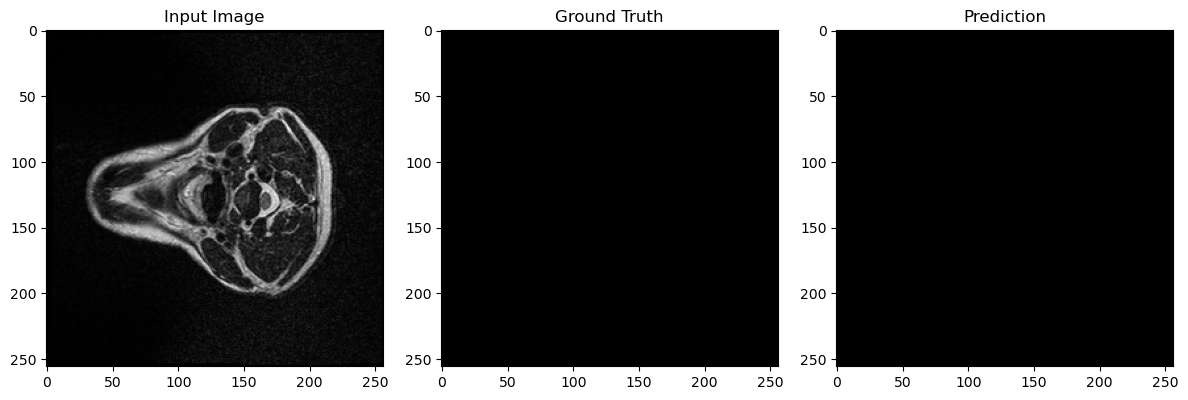

Saved new best model with Val Dice: 0.3591177761554718
Epoch 42/200
  Training Loss: 0.5100, Training Dice: 0.3868
  Validation Dice: 0.3591
Epoch 43/200
  Training Loss: 0.5027, Training Dice: 0.3915
  Validation Dice: 0.3253
EarlyStopping counter: 1/20
Epoch 44/200
  Training Loss: 0.4961, Training Dice: 0.3985
  Validation Dice: 0.2235
EarlyStopping counter: 2/20
Epoch 45/200
  Training Loss: 0.4921, Training Dice: 0.3973
  Validation Dice: 0.2687
EarlyStopping counter: 3/20
Epoch 46/200
  Training Loss: 0.4891, Training Dice: 0.4088
  Validation Dice: 0.3328
EarlyStopping counter: 4/20
Epoch 47/200
  Training Loss: 0.4825, Training Dice: 0.3897
  Validation Dice: 0.3279
EarlyStopping counter: 5/20
Epoch 48/200
  Training Loss: 0.4784, Training Dice: 0.4004
  Validation Dice: 0.2739
EarlyStopping counter: 6/20
Epoch 49/200
  Training Loss: 0.4862, Training Dice: 0.3870
  Validation Dice: 0.2176
EarlyStopping counter: 7/20
Epoch 50/200
  Training Loss: 0.4818, Training Dice: 0.3978
 

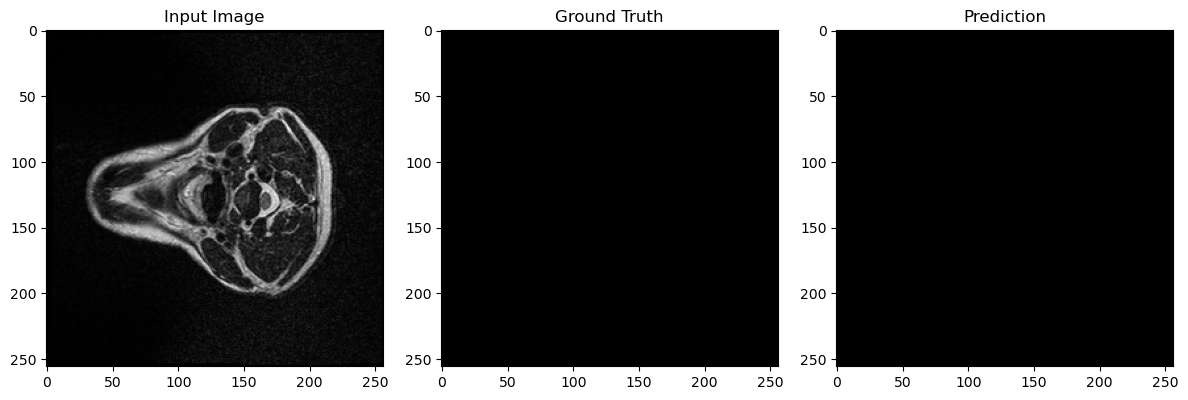

Epoch 52/200
  Training Loss: 0.4585, Training Dice: 0.4201
  Validation Dice: 0.3239
EarlyStopping counter: 10/20
Saved new best model with Val Dice: 0.4344147741794586
Epoch 53/200
  Training Loss: 0.4440, Training Dice: 0.4294
  Validation Dice: 0.4344
Saved new best model with Val Dice: 0.44368305802345276
Epoch 54/200
  Training Loss: 0.4433, Training Dice: 0.4288
  Validation Dice: 0.4437
Epoch 55/200
  Training Loss: 0.4412, Training Dice: 0.4499
  Validation Dice: 0.1650
EarlyStopping counter: 1/20
Epoch 56/200
  Training Loss: 0.4343, Training Dice: 0.4485
  Validation Dice: 0.3189
EarlyStopping counter: 2/20
Epoch 57/200
  Training Loss: 0.4302, Training Dice: 0.4499
  Validation Dice: 0.3002
EarlyStopping counter: 3/20
Epoch 58/200
  Training Loss: 0.4185, Training Dice: 0.4664
  Validation Dice: 0.2364
EarlyStopping counter: 4/20
Epoch 59/200
  Training Loss: 0.4254, Training Dice: 0.4639
  Validation Dice: 0.2214
EarlyStopping counter: 5/20
Epoch 60/200
  Training Loss: 0.

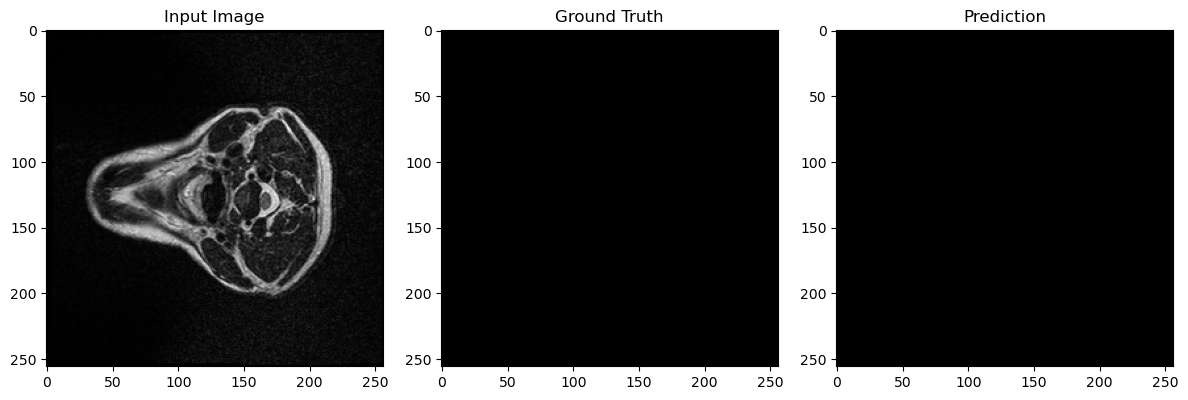

Epoch 62/200
  Training Loss: 0.4079, Training Dice: 0.4833
  Validation Dice: 0.3061
EarlyStopping counter: 8/20
Epoch 63/200
  Training Loss: 0.4054, Training Dice: 0.4746
  Validation Dice: 0.3342
EarlyStopping counter: 9/20
Epoch 64/200
  Training Loss: 0.4027, Training Dice: 0.4744
  Validation Dice: 0.4080
EarlyStopping counter: 10/20
Epoch 65/200
  Training Loss: 0.3996, Training Dice: 0.5030
  Validation Dice: 0.2998
EarlyStopping counter: 11/20
Epoch 66/200
  Training Loss: 0.3940, Training Dice: 0.4891
  Validation Dice: 0.3171
EarlyStopping counter: 12/20
Epoch 67/200
  Training Loss: 0.3920, Training Dice: 0.4992
  Validation Dice: 0.2843
EarlyStopping counter: 13/20
Epoch 68/200
  Training Loss: 0.3903, Training Dice: 0.5079
  Validation Dice: 0.3402
EarlyStopping counter: 14/20
Epoch 69/200
  Training Loss: 0.3898, Training Dice: 0.4981
  Validation Dice: 0.3100
EarlyStopping counter: 15/20
Epoch 70/200
  Training Loss: 0.3962, Training Dice: 0.4920
  Validation Dice: 0.3

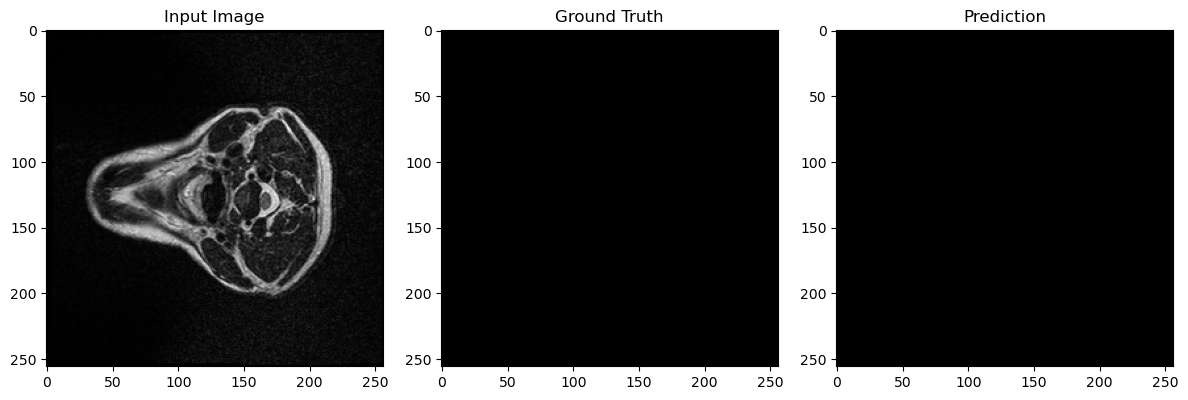

Epoch 72/200
  Training Loss: 0.3910, Training Dice: 0.5032
  Validation Dice: 0.2870
EarlyStopping counter: 18/20
Saved new best model with Val Dice: 0.48165130615234375
Epoch 73/200
  Training Loss: 0.3847, Training Dice: 0.5120
  Validation Dice: 0.4817
Epoch 74/200
  Training Loss: 0.3815, Training Dice: 0.5223
  Validation Dice: 0.2917
EarlyStopping counter: 1/20
Epoch 75/200
  Training Loss: 0.3802, Training Dice: 0.5119
  Validation Dice: 0.3485
EarlyStopping counter: 2/20
Epoch 76/200
  Training Loss: 0.3771, Training Dice: 0.5074
  Validation Dice: 0.2380
EarlyStopping counter: 3/20
Epoch 77/200
  Training Loss: 0.3779, Training Dice: 0.5238
  Validation Dice: 0.3195
EarlyStopping counter: 4/20
Epoch 78/200
  Training Loss: 0.3746, Training Dice: 0.5360
  Validation Dice: 0.4029
EarlyStopping counter: 5/20
Epoch 79/200
  Training Loss: 0.3710, Training Dice: 0.5385
  Validation Dice: 0.3446
EarlyStopping counter: 6/20
Epoch 80/200
  Training Loss: 0.3729, Training Dice: 0.5228

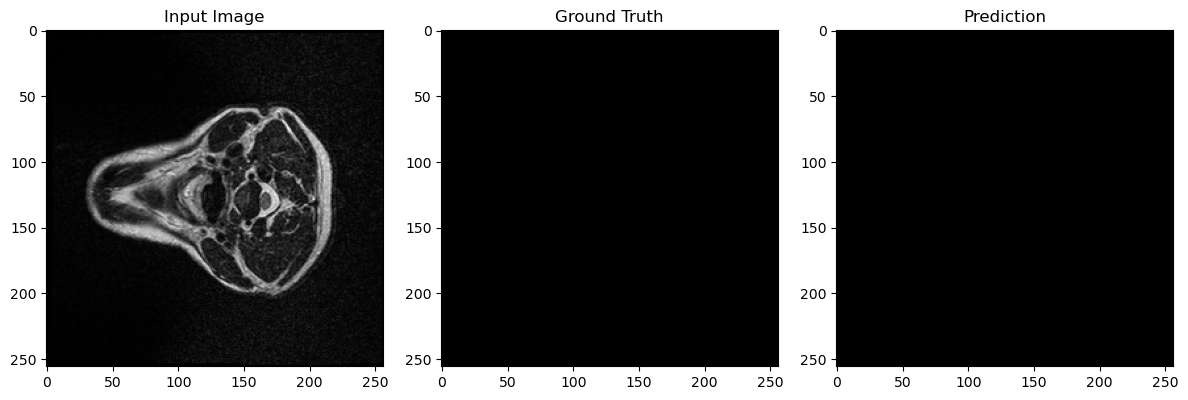

Epoch 82/200
  Training Loss: 0.3711, Training Dice: 0.5237
  Validation Dice: 0.3512
EarlyStopping counter: 9/20
Epoch 83/200
  Training Loss: 0.3675, Training Dice: 0.5366
  Validation Dice: 0.2884
EarlyStopping counter: 10/20
Epoch 84/200
  Training Loss: 0.3675, Training Dice: 0.5375
  Validation Dice: 0.1966
EarlyStopping counter: 11/20
Epoch 85/200
  Training Loss: 0.3539, Training Dice: 0.5421
  Validation Dice: 0.3248
EarlyStopping counter: 12/20
Epoch 86/200
  Training Loss: 0.3653, Training Dice: 0.5428
  Validation Dice: 0.3304
EarlyStopping counter: 13/20
Epoch 87/200
  Training Loss: 0.3602, Training Dice: 0.5544
  Validation Dice: 0.3048
EarlyStopping counter: 14/20
Epoch 88/200
  Training Loss: 0.3431, Training Dice: 0.5775
  Validation Dice: 0.2424
EarlyStopping counter: 15/20
Epoch 89/200
  Training Loss: 0.3567, Training Dice: 0.5586
  Validation Dice: 0.2985
EarlyStopping counter: 16/20
Epoch 90/200
  Training Loss: 0.3535, Training Dice: 0.5582
  Validation Dice: 0.

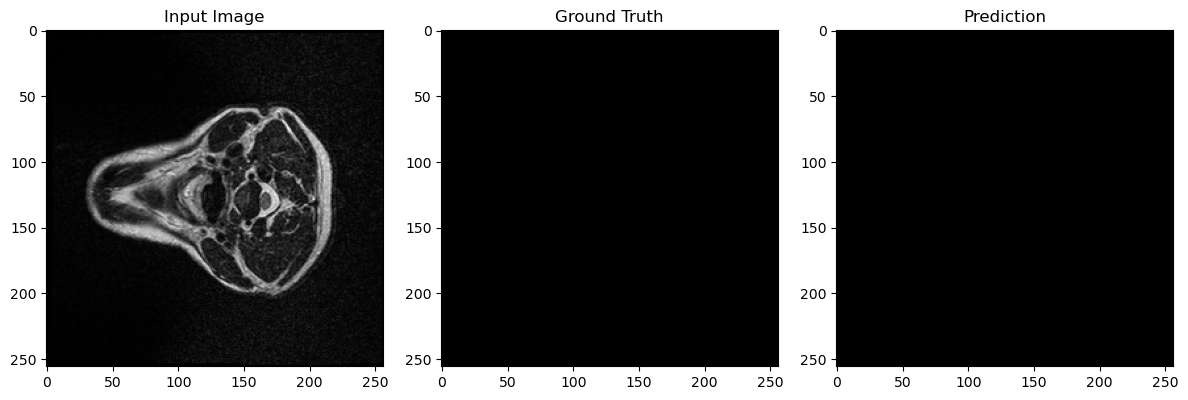

Epoch 92/200
  Training Loss: 0.3516, Training Dice: 0.5558
  Validation Dice: 0.2937
EarlyStopping counter: 19/20
Epoch 93/200
  Training Loss: 0.3619, Training Dice: 0.5468
  Validation Dice: 0.2822
EarlyStopping counter: 20/20
Early stopping at epoch 93. Best epoch was 73.


In [ ]:
num_epochs = 200
best_val_dice = 0.0
train_losses, train_dices, val_dices = [], [], []

# Training loop
for epoch in range(num_epochs):
    # Training phase
    model.train()
    epoch_loss = 0.0
    epoch_train_dice = 0.0
    train_dice_metric.reset()

    for batch_data in train_loader:
        images = batch_data["image"].to(device)
        labels = batch_data["label"].to(device)

        optimizer.zero_grad() # clear old gradients
        with autocast(device_type="cuda"): # Forward pass in mixed precision
            outputs = model(images)
            loss = loss_function(outputs, labels)

        scaler.scale(loss).backward() # Compute gradients with b-pass with scaled loss
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0) # Limit exploding gradients
        scaler.step(optimizer)
        scaler.update()

        epoch_loss += loss.item()
        outputs = torch.softmax(outputs, dim=1) # softmax for multiclass
        preds = torch.argmax(outputs, dim=1, keepdim=True) # converting to a class
        train_dice_metric(preds, labels)

    epoch_loss /= len(train_loader)
    epoch_train_dice = train_dice_metric.aggregate().item()
    scheduler.step()

    # Validation phase
    model.eval()
    epoch_val_dice = 0.0
    val_dice_metric.reset()
    with torch.no_grad(): # disable gradient computation
        for batch_data in val_loader:
            images = batch_data["image"].to(device)
            labels = batch_data["label"].to(device)
            with autocast(device_type="cuda"):
                outputs = sliding_window_inference( # to handle 3d volume and have correct output shape
                    images,
                    roi_size=[256, 256, 64],
                    sw_batch_size=1,
                    predictor=model,
                    overlap=0.25 # for smoother output
                )
            outputs = torch.softmax(outputs, dim=1)
            preds = torch.argmax(outputs, dim=1, keepdim=True)
            val_dice_metric(preds, labels)

    epoch_val_dice = val_dice_metric.aggregate().item()

    if epoch_val_dice > best_val_dice:
        best_val_dice = epoch_val_dice
        torch.save(model.state_dict(), "best_model.pth")
        print("Saved new best model with Val Dice:", best_val_dice)

    train_losses.append(epoch_loss)
    train_dices.append(epoch_train_dice)
    val_dices.append(epoch_val_dice)

    print(f"Epoch {epoch+1}/{num_epochs}")
    print(f"  Training Loss: {epoch_loss:.4f}, Training Dice: {epoch_train_dice:.4f}")
    print(f"  Validation Dice: {epoch_val_dice:.4f}")

    # Early stopping check
    early_stopping(epoch_val_dice, epoch)
    if early_stopping.early_stop:
        print(f"Early stopping at epoch {epoch+1}. Best epoch was {early_stopping.best_epoch+1}.")
        break

    if epoch % 10 == 0:
        slice_idx = 32 
        plt.figure(figsize=(12,4))
        plt.subplot(1, 3, 1)
        plt.imshow(images[0, 0, :, :, slice_idx].cpu(), cmap='gray')
        plt.title('Input Image')
        
        plt.subplot(1, 3, 2)
        plt.imshow(labels[0, 0, :, :, slice_idx].cpu(), cmap='gray')
        plt.title('Ground Truth')
        
        plt.subplot(1, 3, 3)
        plt.imshow(preds[0, 0, :, :, slice_idx].cpu(), cmap='gray')
        plt.title('Prediction')

        plt.tight_layout()
        plt.show()

<h3>Visualization of Training</h3>

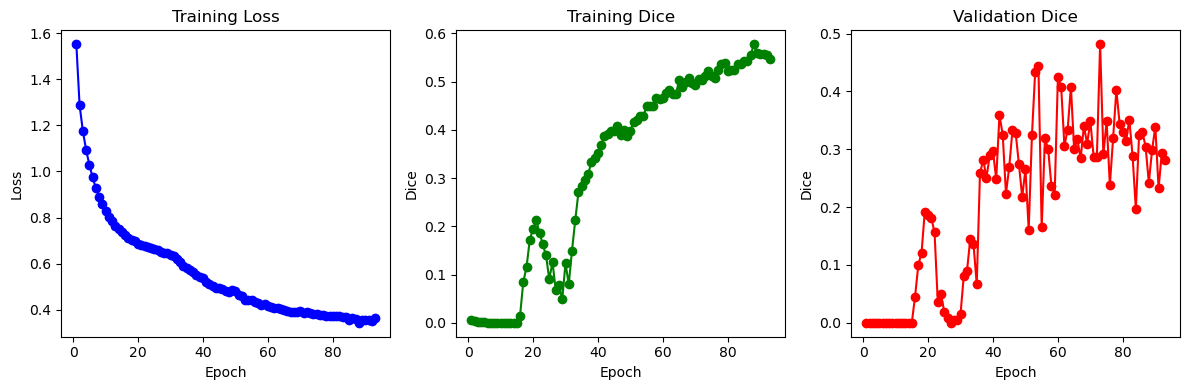

In [ ]:
# Use of ChatGPT for help with plotting
epochs = range(1, 93+1)
plt.figure(figsize=(12,4))
plt.subplot(1,3,1)
plt.plot(epochs, train_losses, 'b-o')
plt.title('Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')

plt.subplot(1,3,2)
plt.plot(epochs, train_dices, 'g-o')
plt.title('Training Dice')
plt.xlabel('Epoch')
plt.ylabel('Dice')

plt.subplot(1,3,3)
plt.plot(epochs, val_dices, 'r-o')
plt.title('Validation Dice')
plt.xlabel('Epoch')
plt.ylabel('Dice')

plt.tight_layout()
plt.show()

<h3>Evaluation</h3>

In [ ]:
test_base_dir = "/datasets/tdt4265/mic/open/HNTS-MRG/test" 

test_case_dirs = sorted(glob.glob(os.path.join(test_base_dir, "*")))
test_data = []

for case_dir in test_case_dirs:
    case_id = os.path.basename(case_dir)
    image_path = os.path.join(case_dir, "preRT", f"{case_id}_preRT_T2.nii.gz")
    label_path = os.path.join(case_dir, "preRT", f"{case_id}_preRT_mask.nii.gz")

    if os.path.exists(image_path) and os.path.exists(label_path):
        test_data.append({"image": image_path, "label": label_path})
    else:
        print(f"Missing data for case {case_id}, skipping.")

print(f"Found {len(test_data)} test samples.")

Found 20 test samples.


In [ ]:
test_transforms = Compose([
    LoadImaged(keys=["image", "label"]),
    EnsureChannelFirstd(keys=["image", "label"]),
    Spacingd(keys=["image", "label"], pixdim=(1.0,1.0,2.0), mode=("bilinear", "nearest")), # Same as in training
    NormalizeIntensityd(keys=["image"]),
    ToTensord(keys=["image", "label"]),
    EnsureTyped(keys=["image", "label"]),
])

# Create the test dataset and DataLoader
test_dataset = Dataset(data=test_data, transform=test_transforms)
test_loader = DataLoader(test_dataset, batch_size=1, shuffle=False, num_workers=2, persistent_workers=True, pin_memory=True) # No shuffling for evaluation 

In [ ]:
# Load the model and set it to evaluation mode
model = AttentionUnet(
    spatial_dims=3,
    in_channels=1,
    out_channels=3,
    channels=(32, 64, 128, 256, 512),
    strides=(2, 2, 2, 2),
    dropout=0.2,
).to(device)
model.load_state_dict(torch.load("best_model.pth"))
model.eval()

# Initialize same lossfunction and metric for Dice score
loss_function = DiceCELoss(include_background=True, to_onehot_y=True, softmax=True)
test_dice_metric = DiceMetric(include_background=True, reduction="mean")

test_loss_total = 0.0
test_dice_metric.reset()

with torch.no_grad(): # same as in validation
    for i, test_batch in enumerate(test_loader):
        images = test_batch["image"].to(device)
        labels = test_batch["label"].to(device) 

        affine = images.meta["affine"].cpu().numpy() # getting original affine, as voxel spacing will be normalized
        if affine.shape == (1, 4, 4):
            affine = affine[0]

        with autocast(device_type="cuda"):
            outputs = sliding_window_inference(
                images,
                roi_size=(256, 256, 64),
                sw_batch_size=1,
                predictor=model,
                overlap=0.25
            )

        loss = loss_function(outputs, labels)
        test_loss_total += loss.item()

        outputs = torch.softmax(outputs, dim=1)
        preds = torch.argmax(outputs, dim=1, keepdim=True)
        test_dice_metric(preds, labels)

        # Save Predictions
        save_dir = os.path.join(os.getcwd(), "test_predictions_v9")
        os.makedirs(save_dir, exist_ok=True)
        pred_np = preds.squeeze().cpu().numpy().astype(np.uint8)
        case_id = os.path.basename(test_case_dirs[i])
        save_path = os.path.join(save_dir, f"{case_id}_prediction.nii.gz")
        nib.save(nib.Nifti1Image(pred_np, affine), save_path)

# Average over all test samples
avg_test_loss = test_loss_total / len(test_loader)
avg_test_dice = test_dice_metric.aggregate().item()

print(f"Test Loss: {avg_test_loss:.4f}")
print(f"Test Dice: {avg_test_dice:.4f}")


/tmp/ipykernel_110732/1217355453.py:10: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("best_model.pth"))


Test Loss: 0.3996
Test Dice: 0.4387


<h3>Visualization</h3>

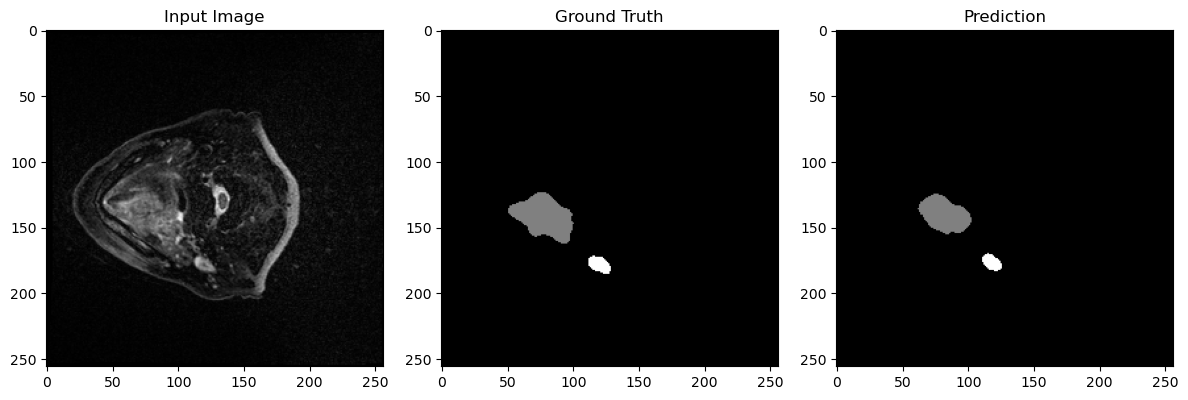

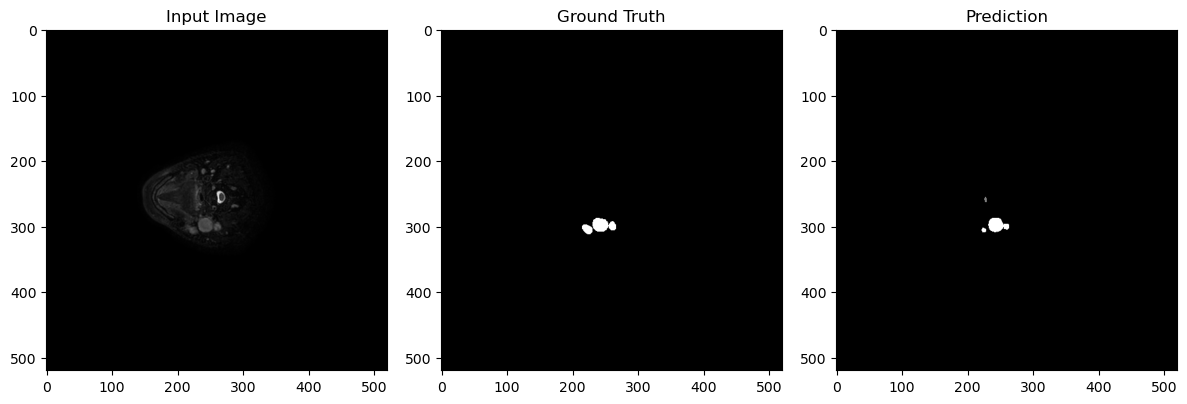

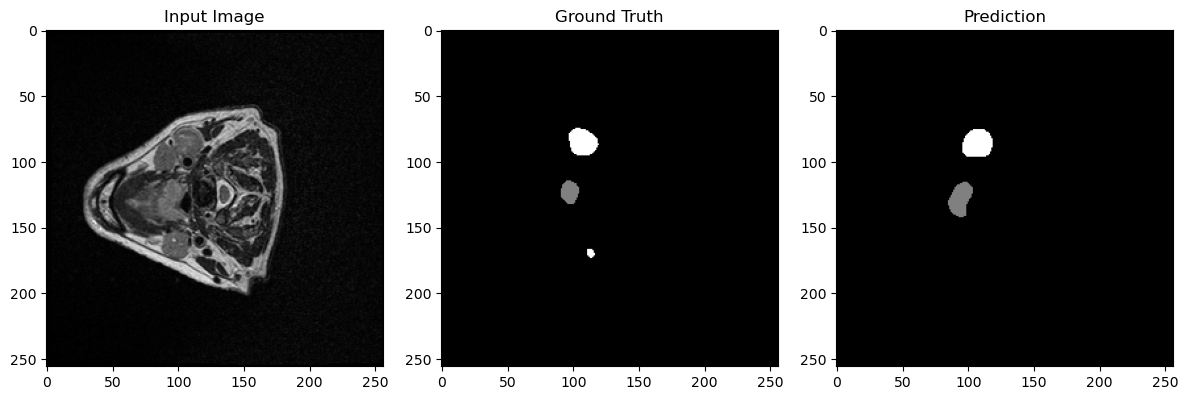

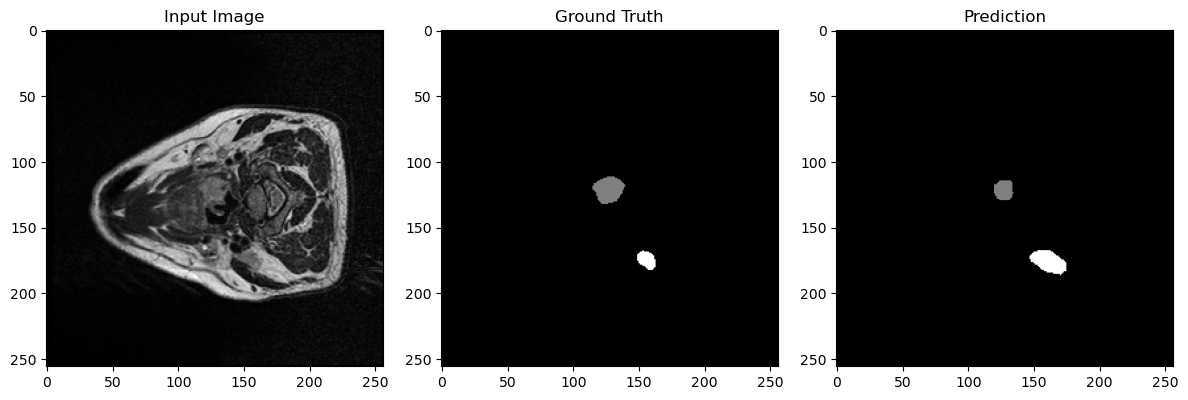

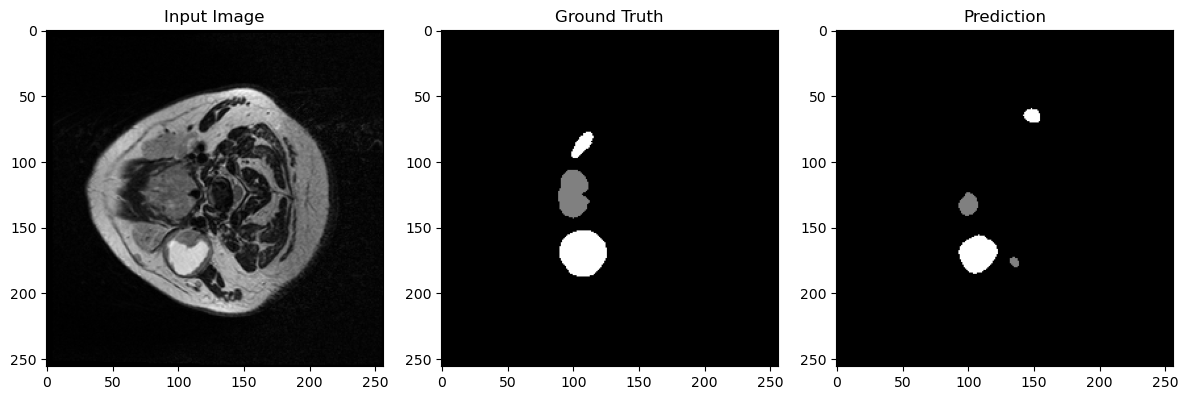

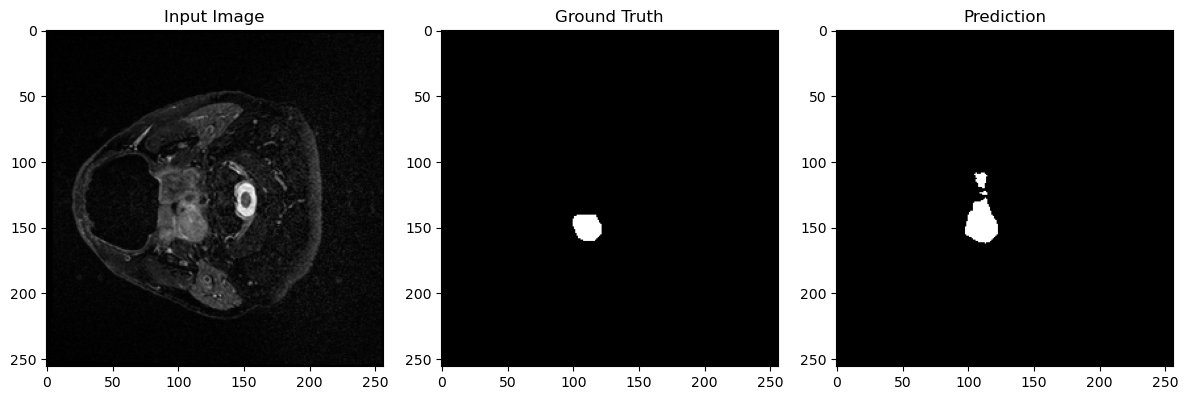

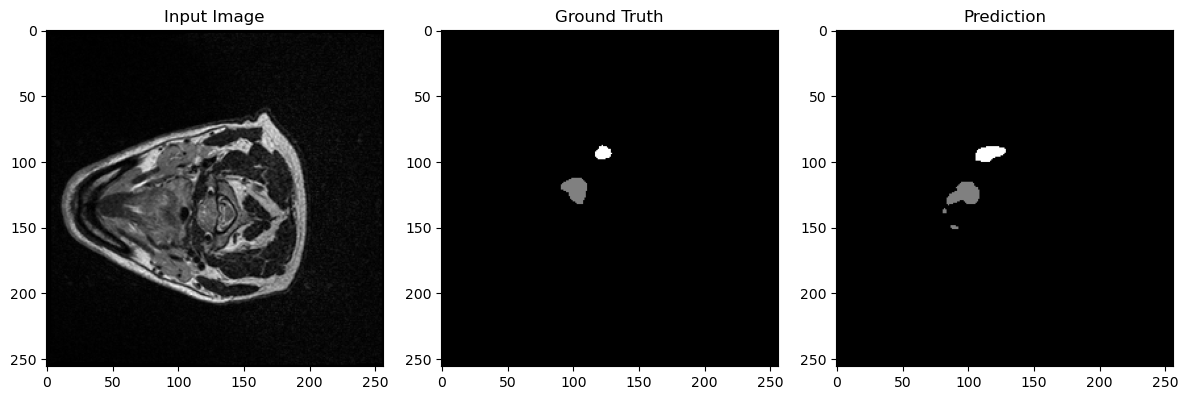

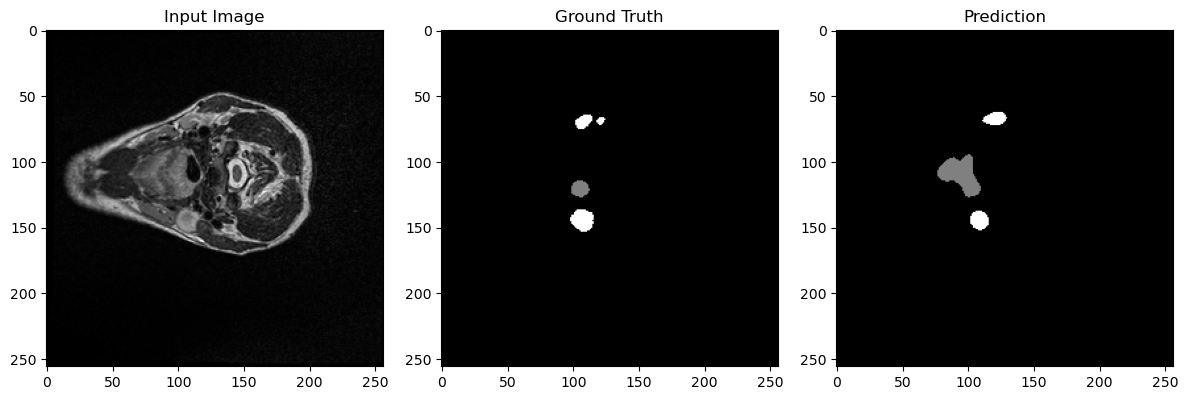

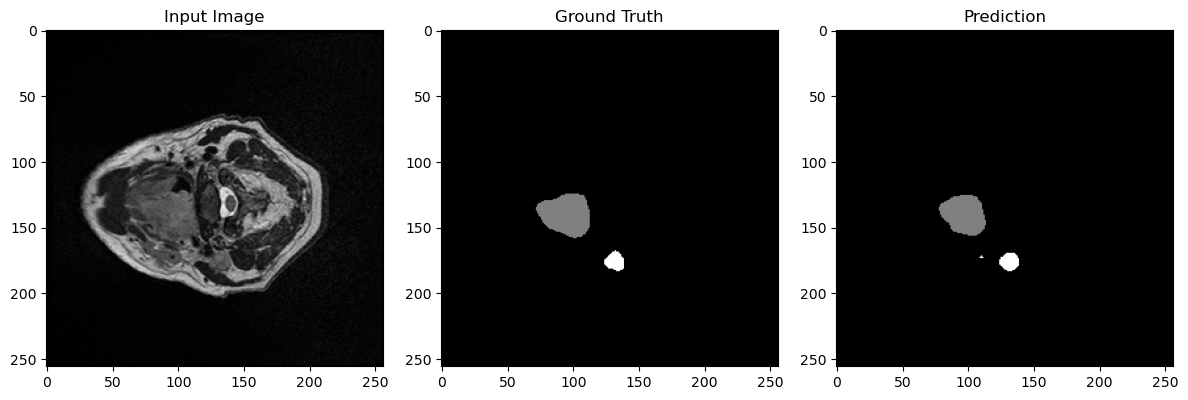

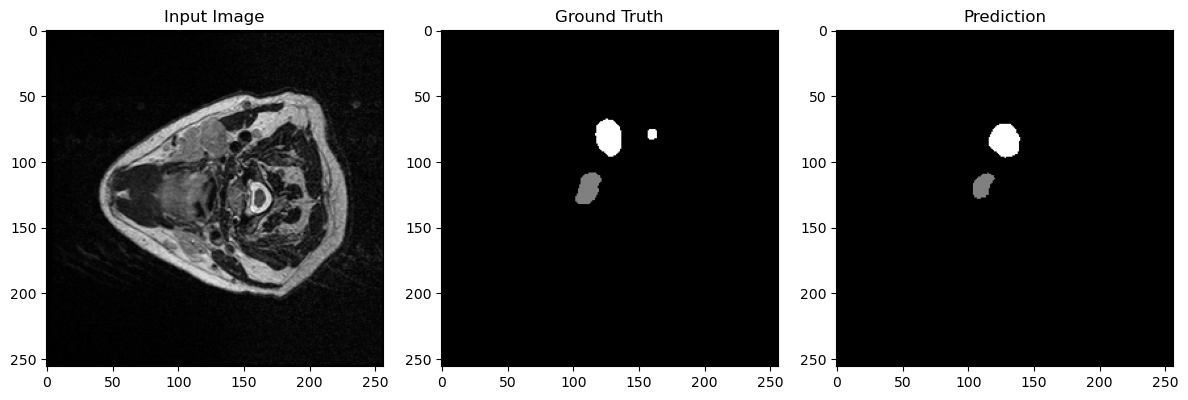

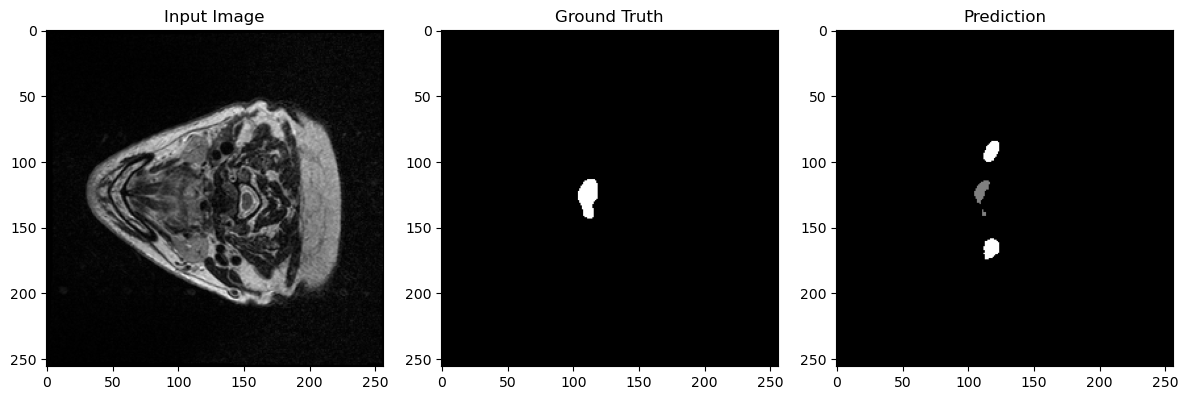

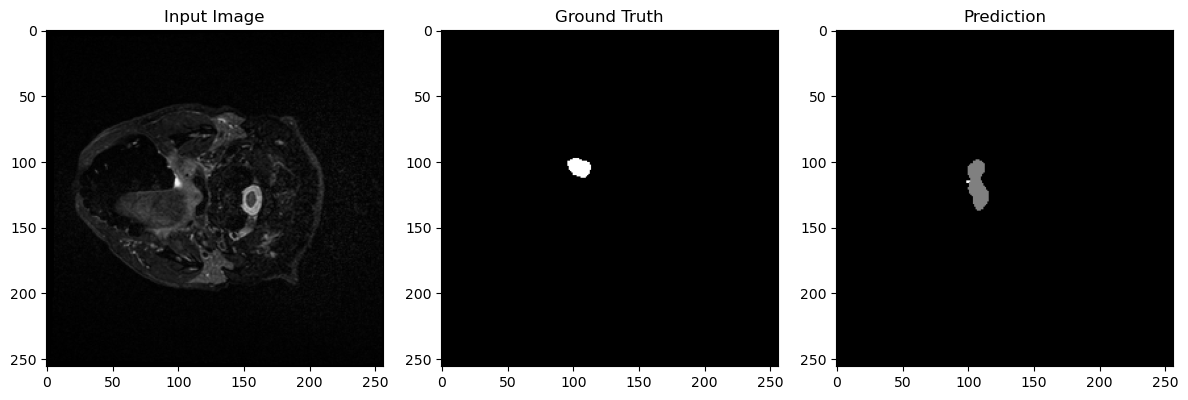

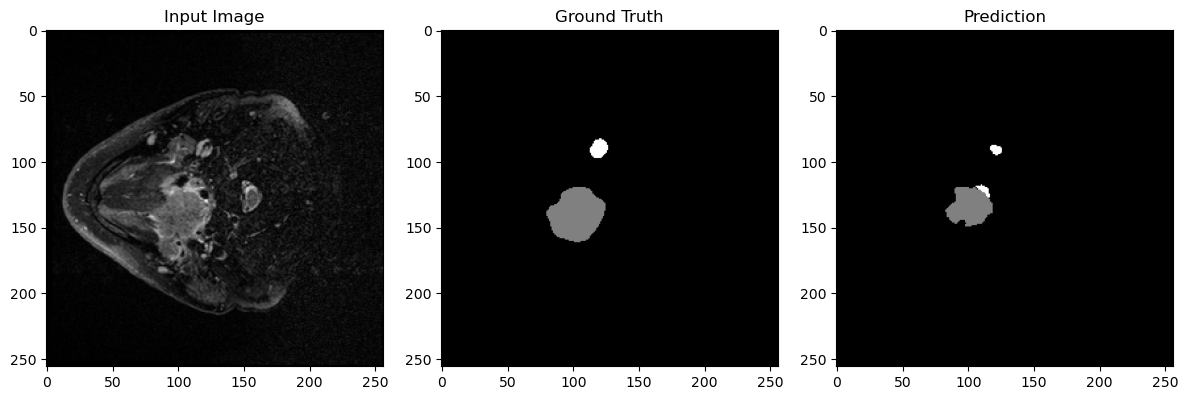

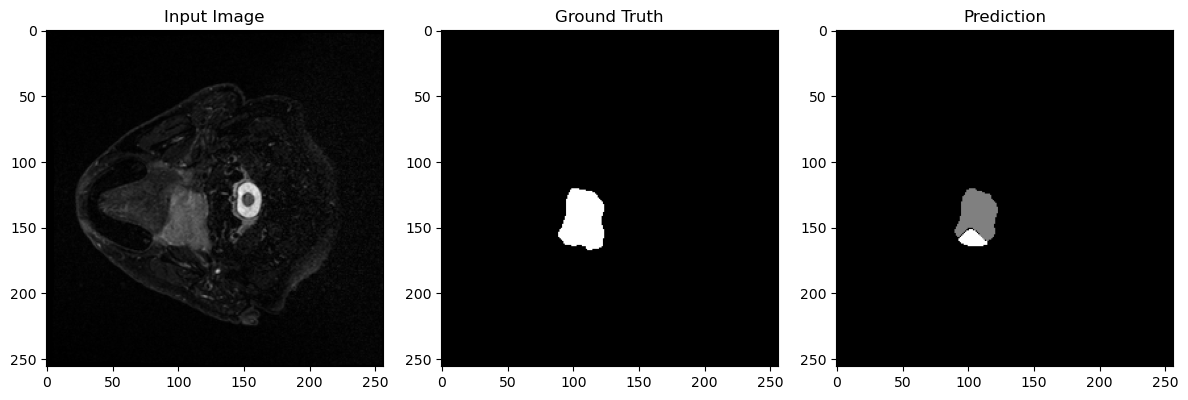

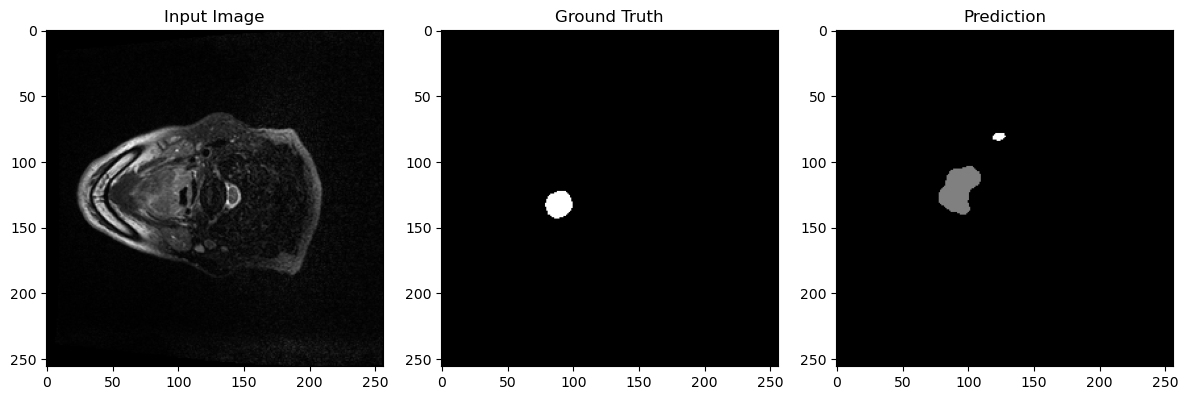

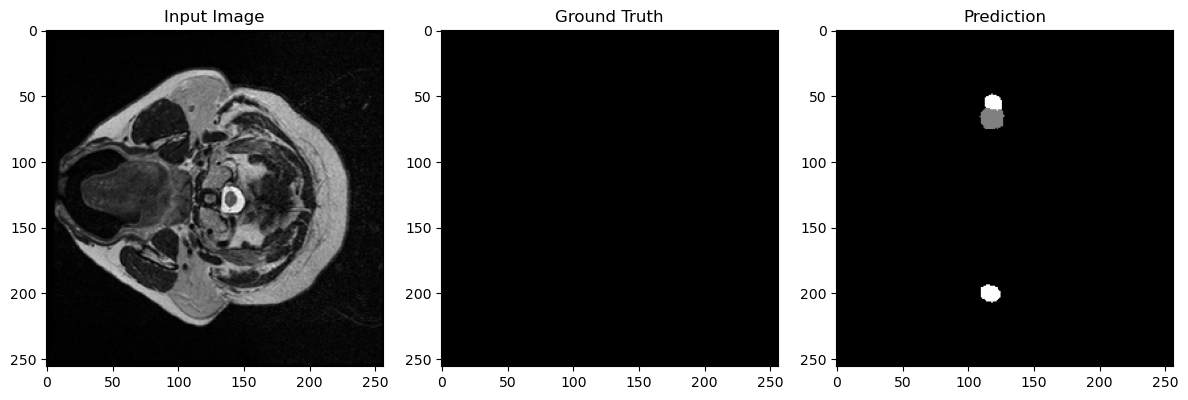

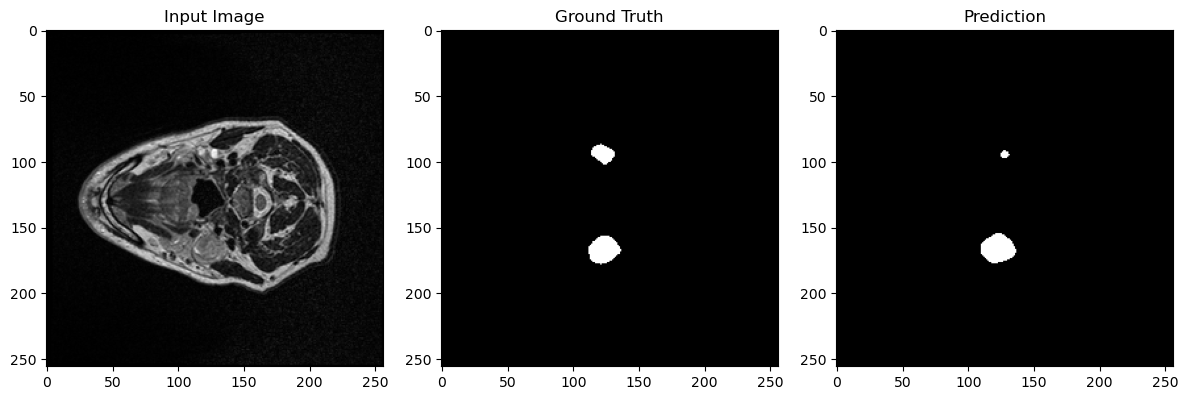

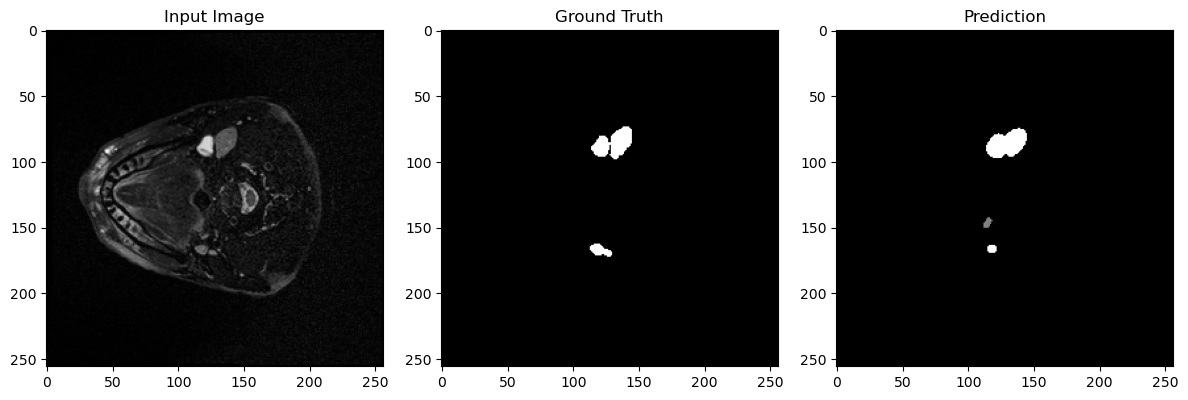

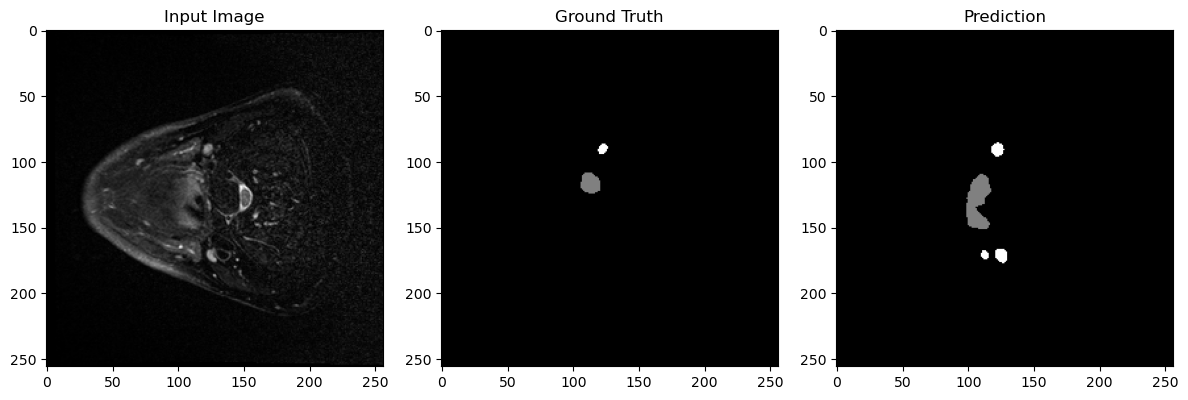

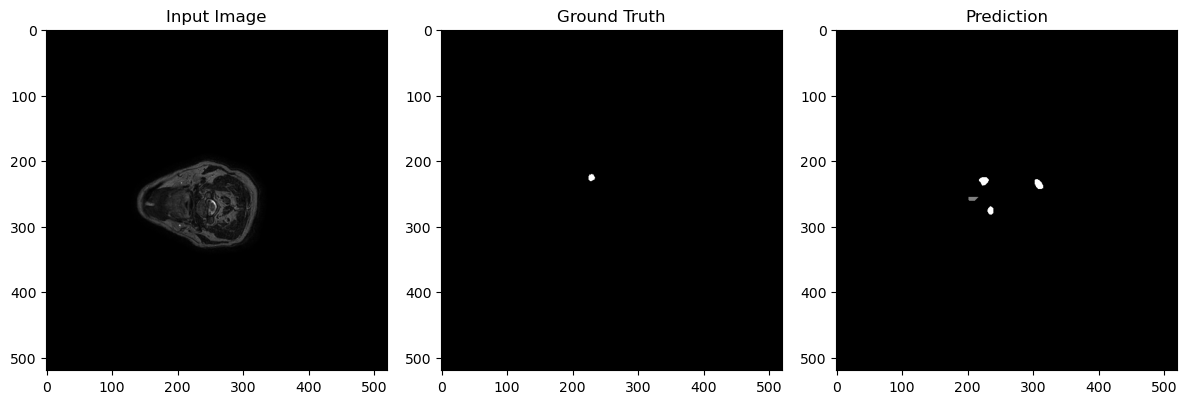

In [ ]:
# Ensure model is in eval mode
model.eval()

# Loop through test dataset
for batch_data in test_loader:
    images = batch_data["image"].to(device)
    labels = batch_data["label"].to(device)

    with torch.no_grad(): # Inference with sliding window
        outputs = sliding_window_inference(
            images, roi_size=(256, 256, 64), sw_batch_size=1, predictor=model, overlap=0.25
        )
        outputs = torch.softmax(outputs, dim=1)
        preds = torch.argmax(outputs, dim=1, keepdim=True)

    # Move everything to CPU
    images = images.cpu()
    labels = labels.cpu()
    preds = preds.cpu()

    # Remove batch and channel dimensions
    image = images[0, 0]
    label = labels[0, 0]  
    pred = preds[0, 0]   

    # slice with most tumor
    tumor_sums = pred.numpy().sum(axis=(0, 1))
    slice_idx = tumor_sums.argmax()

    plt.figure(figsize=(12, 4))

    plt.subplot(1, 3, 1)
    plt.imshow(image[:, :, slice_idx], cmap='gray')
    plt.title('Input Image')

    plt.subplot(1, 3, 2)
    plt.imshow(label[:, :, slice_idx], cmap='gray')
    plt.title('Ground Truth')

    plt.subplot(1, 3, 3)
    plt.imshow(pred[:, :, slice_idx], cmap='gray')
    plt.title('Prediction')

    plt.tight_layout()
    plt.show()
